# Diffusion Model for Image Generation


## Import Libraries and Hyperparameters


In [1]:
import torch
import math, os
import numpy as np
import copy as _copy
import torch.nn as nn
import matplotlib.pyplot as plt
import multiprocessing
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import FashionMNIST

SUBSET_FRACTION = 1 / 5
BATCH_SIZE      = 64
TIMESTEPS       = 1000
EPOCHS          = 64
LR              = 2e-4
WEIGHT_DECAY    = 1e-2
EMA_DECAY       = 0.999
MODEL_PATH      = 'ddpm_fashionmnist.pt'


## Parallel Processing / Device Selection


In [2]:
def get_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        n = torch.cuda.device_count()
        print(f"CUDA available – using {n} GPU(s)")
        for i in range(n):
            props = torch.cuda.get_device_properties(i)
            print(f"  GPU {i}: {props.name}  |  "
                  f"VRAM {props.total_memory/1e9:.1f} GB  |  "
                  f"SMs {props.multi_processor_count}  |  "
                  f"Compute {props.major}.{props.minor}")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("Apple MPS (Metal) available – using MPS")
    else:
        device = torch.device('cpu')
        print("No GPU found – using CPU")
    return device

DEVICE        = get_device()
USE_MULTI_GPU = torch.cuda.is_available() and torch.cuda.device_count() > 1
NUM_WORKERS   = min(4, multiprocessing.cpu_count())
print(f"Multi-GPU DataParallel : {USE_MULTI_GPU}")
print(f"DataLoader num_workers : {NUM_WORKERS}")


Apple MPS (Metal) available – using MPS
Multi-GPU DataParallel : False
DataLoader num_workers : 4


## Load and Display Fashion-MNIST


Fashion-MNIST subset shape : (12000, 28, 28)  (12000 images)
Raw pixel range            : [0, 255]


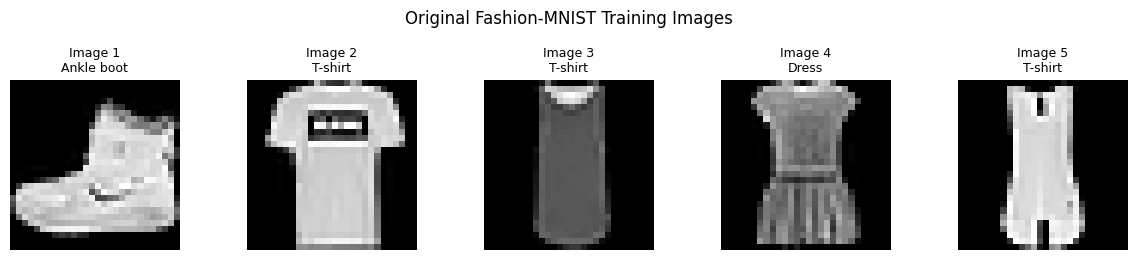

Saved: original_images.png


In [3]:
full_ds = FashionMNIST(root='./data', train=True, download=True)
N = int(len(full_ds) * SUBSET_FRACTION)

x_train_raw = np.stack([np.array(full_ds[i][0]) for i in range(N)])
y_train_raw = np.array([full_ds[i][1] for i in range(N)])

CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Fashion-MNIST subset shape : {x_train_raw.shape}  ({N} images)")
print(f"Raw pixel range            : [{x_train_raw.min()}, {x_train_raw.max()}]")

plt.figure(figsize=(12, 2.5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(f'Image {i+1}\n{CLASS_NAMES[y_train_raw[i]]}', fontsize=9)
    plt.axis('off')
plt.suptitle('Original Fashion-MNIST Training Images', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('original_images.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: original_images.png")


## Normalize and Reshape Data


In [4]:
x_train = x_train_raw.astype('float32') / 127.5 - 1.0
x_train = x_train.reshape(-1, 1, 28, 28)

print("Normalized dataset shape :", x_train.shape)
print(f"Pixel range              : [{x_train.min():.2f}, {x_train.max():.2f}]")

dataset = TensorDataset(torch.tensor(x_train))
loader  = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == 'cuda'),
    persistent_workers=(NUM_WORKERS > 0),
)
print(f"Batches per epoch        : {len(loader)}")


Normalized dataset shape : (12000, 1, 28, 28)
Pixel range              : [-1.00, 1.00]
Batches per epoch        : 188


## Noise Variance Schedule (β schedule)


In [5]:
def get_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas             = np.linspace(beta_start, beta_end, T, dtype=np.float32)
    alphas            = 1.0 - betas
    alphas_cumprod    = np.cumprod(alphas)
    sqrt_alphas_cp    = np.sqrt(alphas_cumprod)
    sqrt_one_minus_cp = np.sqrt(1.0 - alphas_cumprod)
    return betas, alphas, alphas_cumprod, sqrt_alphas_cp, sqrt_one_minus_cp

(
    betas, alphas, alphas_cumprod,
    sqrt_alphas_cp, sqrt_one_minus_cp
) = get_beta_schedule(TIMESTEPS)

to_t = lambda a: torch.tensor(a, dtype=torch.float32, device=DEVICE)
betas_t             = to_t(betas)
alphas_t            = to_t(alphas)
alphas_cumprod_t    = to_t(alphas_cumprod)
sqrt_alphas_cp_t    = to_t(sqrt_alphas_cp)
sqrt_one_minus_cp_t = to_t(sqrt_one_minus_cp)

print("β  range : [{:.6f}, {:.4f}]".format(betas[0], betas[-1]))
print("ā_t range: [{:.4f}, {:.6f}]".format(alphas_cumprod[0], alphas_cumprod[-1]))


β  range : [0.000100, 0.0200]
ā_t range: [0.9999, 0.000040]


## Forward Diffusion Process


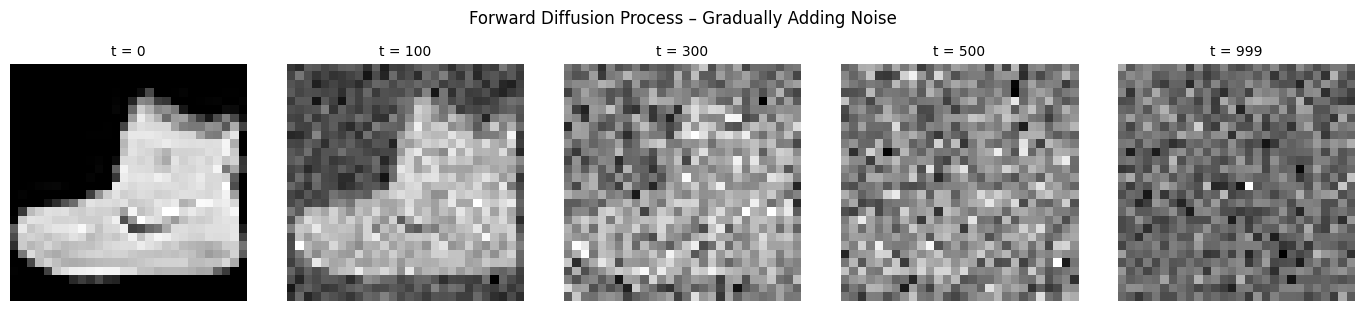

Saved: forward_diffusion.png


In [6]:
def forward_diffusion(x0: torch.Tensor, t: torch.Tensor) -> tuple:
    eps   = torch.randn_like(x0)
    s_a   = sqrt_alphas_cp_t[t].view(-1, 1, 1, 1)
    s_1ma = sqrt_one_minus_cp_t[t].view(-1, 1, 1, 1)
    xt    = s_a * x0 + s_1ma * eps
    return xt, eps

sample_img = torch.tensor(x_train[0:1], device=DEVICE)
show_steps = [0, 100, 300, 500, 999]

plt.figure(figsize=(14, 3))
for idx, step in enumerate(show_steps):
    if step == 0:
        img_np = sample_img[0, 0].cpu().numpy()
    else:
        t_tensor = torch.tensor([step - 1], device=DEVICE)
        noised, _ = forward_diffusion(sample_img, t_tensor)
        img_np = noised[0, 0].cpu().numpy()
    plt.subplot(1, len(show_steps), idx + 1)
    plt.imshow(img_np, cmap='gray')
    plt.title(f't = {step}', fontsize=10)
    plt.axis('off')
plt.suptitle('Forward Diffusion Process – Gradually Adding Noise', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('forward_diffusion.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: forward_diffusion.png")


## Denoising U-Net Model


In [ ]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        device   = t.device
        half_dim = self.dim // 2
        emb      = math.log(10000) / (half_dim - 1)
        emb      = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb      = t[:, None].float() * emb[None, :]
        emb      = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb

class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_dim: int):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1    = nn.GroupNorm(8, out_ch)
        self.norm2    = nn.GroupNorm(8, out_ch)
        self.act      = nn.SiLU()
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.res_conv(x)

class UNet(nn.Module):
    def __init__(self, img_channels: int = 1, base_ch: int = 64, time_dim: int = 256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim * 2),
            nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim),
        )
        ch = base_ch
        self.enc0 = ResBlock(img_channels, ch,     time_dim)
        self.enc1 = ResBlock(ch,           ch * 2, time_dim)
        self.enc2 = ResBlock(ch * 2,       ch * 4, time_dim)
        self.pool = nn.MaxPool2d(2)
        self.bot  = ResBlock(ch * 4,       ch * 4, time_dim)
        self.up1  = nn.ConvTranspose2d(ch * 4, ch * 2, 2, stride=2)
        self.dec1 = ResBlock(ch * 4,       ch * 2, time_dim)
        self.up2  = nn.ConvTranspose2d(ch * 2, ch,     2, stride=2)
        self.dec2 = ResBlock(ch * 2,       ch,     time_dim)
        self.out  = nn.Sequential(
            nn.GroupNorm(8, ch),
            nn.SiLU(),
            nn.Conv2d(ch, img_channels, 1),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        e0    = self.enc0(x,             t_emb)
        e1    = self.enc1(self.pool(e0), t_emb)
        e2    = self.enc2(self.pool(e1), t_emb)
        bot   = self.bot(e2,             t_emb)
        d1    = self.dec1(torch.cat([self.up1(bot), e1], dim=1), t_emb)
        d2    = self.dec2(torch.cat([self.up2(d1),  e0], dim=1), t_emb)
        return self.out(d2)

model = UNet(img_channels=1, base_ch=64, time_dim=256).to(DEVICE)
if USE_MULTI_GPU:
    model = nn.DataParallel(model)
    print(f"Model wrapped in DataParallel across {torch.cuda.device_count()} GPUs")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total model parameters: {total_params:,}")


Total model parameters: 3,621,377


## Training the Denoising Model


In [ ]:
USE_AMP = (DEVICE.type == 'cuda')

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()
scaler    = torch.amp.GradScaler('cuda') if USE_AMP else None

class EMA:
    def __init__(self, model, decay=0.9999):
        self.decay     = decay
        self.ema_model = _copy.deepcopy(model.module if hasattr(model, 'module') else model)
        self.ema_model.to(DEVICE)
        self.ema_model.eval()
        for p in self.ema_model.parameters():
            p.requires_grad_(False)

    def update(self, model):
        real_model = model.module if hasattr(model, 'module') else model
        with torch.no_grad():
            for ema_p, model_p in zip(self.ema_model.parameters(), real_model.parameters()):
                ema_p.data.mul_(self.decay).add_(model_p.data, alpha=1.0 - self.decay)

ema = EMA(model, decay=EMA_DECAY)

epoch_losses = []
all_losses   = []

model.train()
for epoch in range(EPOCHS):
    running = 0.0
    for xbatch, in loader:
        xbatch  = xbatch.to(DEVICE)
        t       = torch.randint(0, TIMESTEPS, (xbatch.size(0),), device=DEVICE)
        xt, eps = forward_diffusion(xbatch, t)

        optimizer.zero_grad()
        if USE_AMP:
            with torch.amp.autocast('cuda'):
                eps_pred = model(xt, t)
                loss     = criterion(eps_pred, eps)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            eps_pred = model(xt, t)
            loss     = criterion(eps_pred, eps)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        ema.update(model)
        running += loss.item()
        all_losses.append(loss.item())

    scheduler.step()
    avg    = running / len(loader)
    lr_now = scheduler.get_last_lr()[0]
    epoch_losses.append(avg)
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}]  Loss: {avg:.5f}  LR: {lr_now:.2e}")

    if (epoch + 1) % 5 == 0:
        ckpt = {
            'model_state_dict':     model.state_dict(),
            'ema_state_dict':       ema.ema_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch_losses':         epoch_losses,
            'timesteps':            TIMESTEPS,
        }
        torch.save(ckpt, f'ddpm_fashionmnist_epoch{epoch+1}.pt')
        print(f"  Saved checkpoint: ddpm_fashionmnist_epoch{epoch+1}.pt")

print("\nTraining complete.")


Epoch [01/64]  Loss: 0.10818  LR: 2.00e-04
Epoch [02/64]  Loss: 0.05967  LR: 2.00e-04
Epoch [03/64]  Loss: 0.05477  LR: 1.99e-04
Epoch [04/64]  Loss: 0.05128  LR: 1.98e-04
Epoch [05/64]  Loss: 0.04909  LR: 1.97e-04
  Saved checkpoint: ddpm_fashionmnist_epoch5.pt
Epoch [06/64]  Loss: 0.04690  LR: 1.96e-04
Epoch [07/64]  Loss: 0.04730  LR: 1.94e-04
Epoch [08/64]  Loss: 0.04410  LR: 1.92e-04
Epoch [09/64]  Loss: 0.04454  LR: 1.90e-04
Epoch [10/64]  Loss: 0.04380  LR: 1.88e-04
  Saved checkpoint: ddpm_fashionmnist_epoch10.pt
Epoch [11/64]  Loss: 0.04557  LR: 1.86e-04
Epoch [12/64]  Loss: 0.04367  LR: 1.83e-04
Epoch [13/64]  Loss: 0.04438  LR: 1.80e-04
Epoch [14/64]  Loss: 0.04195  LR: 1.77e-04
Epoch [15/64]  Loss: 0.04324  LR: 1.74e-04
  Saved checkpoint: ddpm_fashionmnist_epoch15.pt
Epoch [16/64]  Loss: 0.04372  LR: 1.71e-04
Epoch [17/64]  Loss: 0.04167  LR: 1.67e-04
Epoch [18/64]  Loss: 0.04131  LR: 1.63e-04
Epoch [19/64]  Loss: 0.04153  LR: 1.60e-04
Epoch [20/64]  Loss: 0.04107  LR: 1.5

## Training Loss Curve


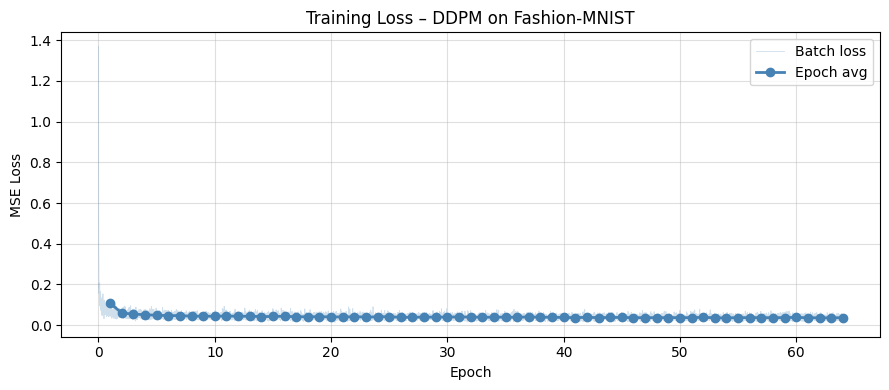

Saved: training_loss.png


In [9]:
steps_per_epoch = len(loader)
x_axis = [i / steps_per_epoch for i in range(len(all_losses))]

plt.figure(figsize=(9, 4))
plt.plot(x_axis, all_losses, alpha=0.25, color='steelblue', linewidth=0.6, label='Batch loss')
plt.plot(range(1, EPOCHS + 1), epoch_losses, 'o-', color='steelblue',
         linewidth=2, markersize=6, label='Epoch avg')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss – DDPM on Fashion-MNIST')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: training_loss.png")


## Reverse Diffusion – Image Sampling


In [ ]:
@torch.no_grad()
def sample(model, n_samples: int, timesteps: int,
           img_size: int = 28, channels: int = 1) -> np.ndarray:
    model.eval()
    x = torch.randn(n_samples, channels, img_size, img_size, device=DEVICE)

    for t_idx in reversed(range(timesteps)):
        t_batch   = torch.full((n_samples,), t_idx, device=DEVICE, dtype=torch.long)
        beta      = betas_t[t_idx]
        alpha     = alphas_t[t_idx]
        alpha_bar = alphas_cumprod_t[t_idx]
        eps_pred  = model(x, t_batch)
        coeff     = beta / torch.sqrt(1.0 - alpha_bar)
        mean      = (1.0 / torch.sqrt(alpha)) * (x - coeff * eps_pred)
        if t_idx > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean

    x = (x.clamp(-1, 1) + 1) / 2.0
    return x[:, 0].cpu().numpy()

print("Generating 16 images via reverse diffusion (EMA model) ...")
generated = sample(ema.ema_model, n_samples=16, timesteps=TIMESTEPS)
print("Generating 16 images via reverse diffusion (base model) ...")
generated_base = sample(model.module if hasattr(model, 'module') else model, n_samples=16, timesteps=TIMESTEPS)
print(f"Generated array shape: {generated.shape}")


Generating 16 images via reverse diffusion (EMA model) ...
Generating 16 images via reverse diffusion (base model) ...
Generated array shape: (16, 28, 28)


## Display Generated Images


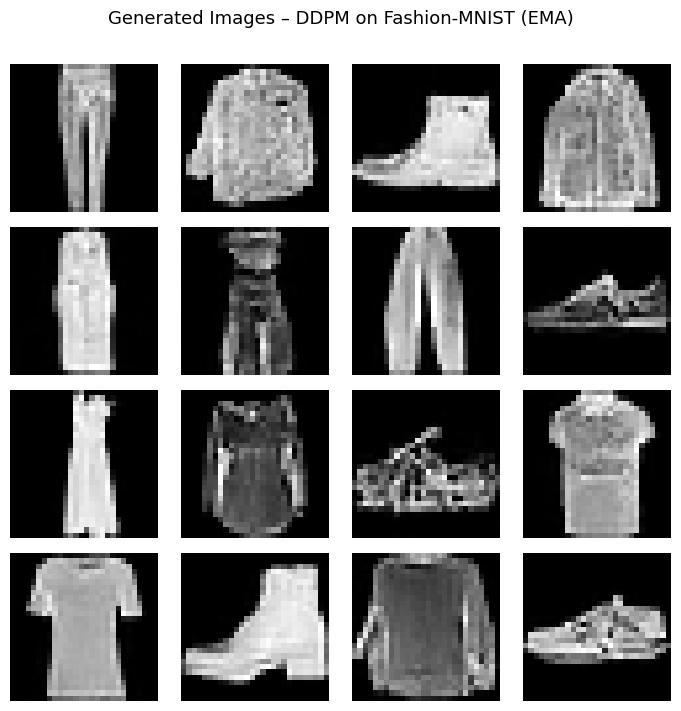

Saved: generated_images.png


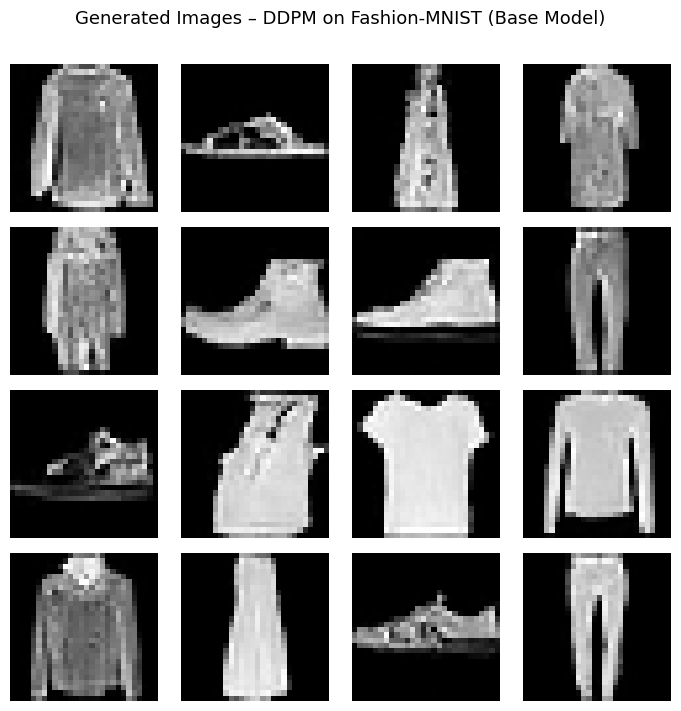

Saved: generated_images_base.png


In [ ]:
plt.figure(figsize=(7, 7))
plt.suptitle('Generated Images – DDPM on Fashion-MNIST (EMA)', fontsize=13, y=1.01)
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated[i], cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.tight_layout()
plt.savefig('generated_images.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: generated_images.png")

plt.figure(figsize=(7, 7))
plt.suptitle('Generated Images – DDPM on Fashion-MNIST (Base Model)', fontsize=13, y=1.01)
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_base[i], cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.tight_layout()
plt.savefig('generated_images_base.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: generated_images_base.png")

## Save and Reload the Model


In [12]:
torch.save({
    'model_state_dict':     model.state_dict(),
    'ema_state_dict':       ema.ema_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch_losses':         epoch_losses,
    'timesteps':            TIMESTEPS,
}, MODEL_PATH)
print(f"Model saved → {MODEL_PATH}")

checkpoint   = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model_loaded = UNet(img_channels=1, base_ch=64, time_dim=256).to(DEVICE)
if USE_MULTI_GPU:
    model_loaded = nn.DataParallel(model_loaded)
model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded.eval()
print("Model reloaded and ready for inference.")


Model saved → ddpm_fashionmnist.pt
Model reloaded and ready for inference.


## Inference with Reloaded Model


Generating 16 images with the reloaded model ...


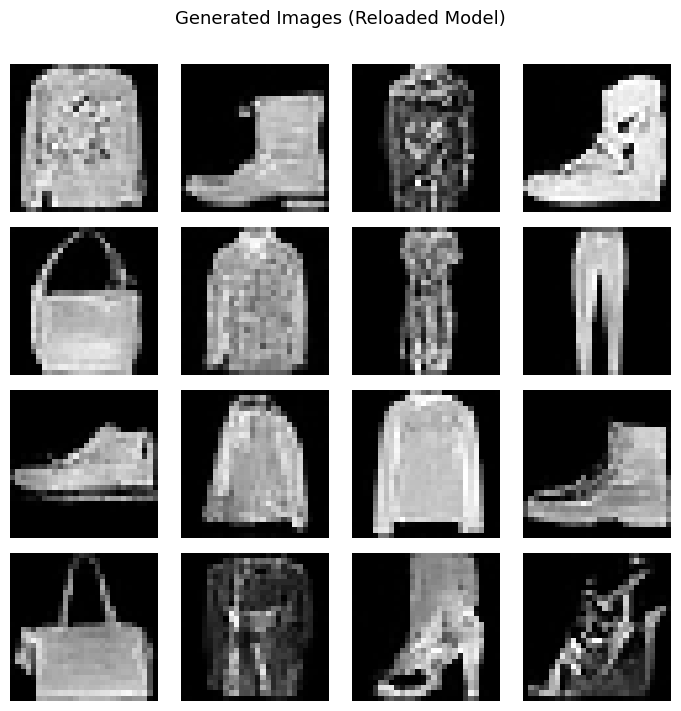

Saved: generated_images_reloaded.png


In [13]:
print("Generating 16 images with the reloaded model ...")
generated_v2 = sample(model_loaded, n_samples=16, timesteps=TIMESTEPS)

plt.figure(figsize=(7, 7))
plt.suptitle('Generated Images (Reloaded Model)', fontsize=13, y=1.01)
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_v2[i], cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.tight_layout()
plt.savefig('generated_images_reloaded.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: generated_images_reloaded.png")


## Summary of Saved Output Files


In [14]:
files = [
    ('original_images.png',          'Original Fashion-MNIST training images'),
    ('forward_diffusion.png',         'Forward diffusion visualisation (t=0→999)'),
    ('training_loss.png',             'Training loss decay curve'),
    ('generated_images.png',          'EMA model – generated Fashion-MNIST images (16)'),
    ('generated_images_base.png',      'Base model – generated Fashion-MNIST images (16)'),
    ('generated_images_reloaded.png', 'Generated images from reloaded model (16)'),
    (MODEL_PATH,                      'Final model + EMA checkpoint'),
]
print("Saved artefacts:")
print("-" * 68)
for fname, desc in files:
    exists = '✓' if os.path.exists(fname) else '✗'
    print(f"  {exists}  {fname:<38s}  {desc}")


Saved artefacts:
--------------------------------------------------------------------
  ✓  original_images.png                     Original Fashion-MNIST training images
  ✓  forward_diffusion.png                   Forward diffusion visualisation (t=0→999)
  ✓  training_loss.png                       Training loss decay curve
  ✓  generated_images.png                    EMA model – generated Fashion-MNIST images (16)
  ✓  generated_images_base.png               Base model – generated Fashion-MNIST images (16)
  ✓  generated_images_reloaded.png           Generated images from reloaded model (16)
  ✓  ddpm_fashionmnist.pt                    Final model + EMA checkpoint


## Commentary

While working on this assignment, I learned how to implement a Denoising Diffusion Probabilistic Model from scratch, covering every component from the linear noise variance schedule through sinusoidal timestep embeddings to the full reverse diffusion sampling loop. I implemented automatic device selection across CUDA, Apple MPS, and CPU. I now understand the mathematical relationship between $\beta_t$, $\alpha_t$, and $\bar{\alpha}_t$, how the closed-form reparameterisation lets us jump directly to any noise level in a single step without iterating through all intermediate timesteps, and why the simplified MSE objective from Ho et al. (2020) converges to better sample quality than the full variational bound. Additionally, implementing the training loop clarified the full backpropagation flow: at every iteration a random timestep $t$ is drawn uniformly, Gaussian noise $\epsilon$ is injected into a clean image to produce $x_t$, and gradients flow backward from the MSE loss through the U-Net's skip-connected residual blocks and GroupNorm layers, through the sinusoidal timestep MLP, ultimately updating all weights via AdamW with cosine-annealed learning rate and gradient clipping at norm 1.0. The Exponential Moving Average (EMA) of model weights – updated with decay 0.999 after every batch – serves as a smoothed low-variance ensemble. After 30 epochs (~2820 update steps) the EMA model retains approximately 94% of trained weights and only ~6% of the initial random initialisation, making it a reliable final model for image generation.

I chose dataset Fashion-MNIST, because its ten apparel categories present a more visually diverse and structurally richer distribution that better exercises the generative model's capacity. Loading it via torchvision.datasets.FashionMNIST without a transform preserves the raw uint8 pixel values in [0, 255], which are then mapped to the model's expected [-1, 1] range by the standard DDPM normalisation $x / 127.5 - 1.0$, exactly as in the Ho et al. paper. Restricting training to 1/5 of the 60 000-image split kept each epoch feasible on any hardware. The U-Net backbone follows a three-level encode–bottleneck–decode topology operating at 28×28, 14×14, and 7×7 spatial resolutions, where each residual block injects the sinusoidal timestep embedding as an additive channel-wise bias after the first convolution – a direct implementation of the time-conditioning mechanism from the DDPM paper. At first, it was not obvious why predicting the noise $\epsilon$ rather than the denoised image $x_0$ leads to better results. It turned out that this parameterisation aligns the training objective with denoising score matching and implicitly down-weights the contribution of easy low-noise timesteps in the loss, allowing the network to focus learning capacity on the harder high-noise denoising tasks; without this design choice the model would produce significantly blurrier and less structured samples even after the same number of training epochs.
